# Parkinson Hastalığı Tespiti — Random Forest Modeli

**Hazırlayan:** Berke Genç  
**Ders:** Makine Öğrenmesi — İstanbul Topkapı Üniversitesi, Yazılım Mühendisliği  
**Algoritma:** Random Forest (Rastgele Orman)

## Bölüm 1 — Veri Seti Tanıtımı

### Veri Seti Bilgileri

- **Veri Seti Adı:** Oxford Parkinson's Disease Detection Dataset (UCI)
- **Kaynak:** [https://archive.ics.uci.edu/dataset/174/parkinsons](https://archive.ics.uci.edu/dataset/174/parkinsons)
- **Problem Türü:** İkili Sınıflandırma (Binary Classification)
- **Hedef Değişken:** `status` → 1 = Parkinson hastası, 0 = Sağlıklı birey

### Veri Seti Hakkında

Bu veri seti, 31 farklı bireyden (23 Parkinson hastası, 8 sağlıklı) alınan **195 ses kaydı** içermektedir. Her kayıt için konuşma sesinden türetilen çeşitli akustik ve biyomedikal özellikler hesaplanmıştır. Bu özellikler arasında:

- **Frekans ölçümleri:** MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz) — temel ses frekansları
- **Jitter ölçümleri:** Ses periyodundaki değişkenlikler (titreşim düzensizliği)
- **Shimmer ölçümleri:** Ses genliğindeki değişkenlikler
- **HNR (Harmonik-Gürültü Oranı):** Sesin harmonikliği
- **RPDE, DFA, D2, PPE:** Doğrusal olmayan dinamik özellikler

Parkinson hastalığı, beyin dopamin sistemini etkileyen nörodejeneratif bir hastalıktır. Bu hastalık, motor kontrol bozukluklarına yol açarak ses üretimini olumsuz etkiler: titrek ses, monoton konuşma ve ses şiddetinin azalması tipik belirtilerdir. Bu nedenle yukarıda belirtilen akustik özellikler, Parkinson tespiti açısından **klinik olarak anlamlı** göstergeler sunmaktadır.

### Bu Notebook Hakkında

Bu notebook, grup projesinin **Random Forest** modelinden sorumlu olan **Berke Genç** tarafından hazırlanmıştır. Veri okuma, istatistiksel analiz, ön işleme ve modelleme adımlarını tek başına çalışabilecek şekilde içermektedir.

## Bölüm 2 — Kütüphaneler ve Veri Okuma

### 2.1 — Gerekli Kütüphanelerin Yüklenmesi

Aşağıda projede kullanılacak tüm kütüphaneler import edilmektedir.

In [7]:
# Temel kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn — model seçimi
from sklearn.model_selection import train_test_split, GridSearchCV

# Sklearn — model
from sklearn.ensemble import RandomForestClassifier

# Sklearn — değerlendirme metrikleri
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Uyarı mesajlarını gizle
warnings.filterwarnings('ignore')

# Grafik ayarları
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


### 2.2 — Veri Setinin Okunması

Standardize edilmiş veri seti (`parkinsons_standardized.csv`) okunmaktadır. Bu dosya, 22 sayısal özelliğe z-score standardizasyonu uygulanmış halini içermektedir.

In [8]:
# Veri setini oku
df = pd.read_csv('data/parkinsons_standardized.csv')

# İlk 5 satırı göster
print("=== İlk 5 Satır ===")
display(df.head())

# Boyut bilgisi
print(f"\n=== Veri Seti Boyutu ===")
print(f"Satır sayısı : {df.shape[0]}")
print(f"Sütun sayısı : {df.shape[1]}")

# Sütun veri tipleri
print("\n=== Sütun Veri Tipleri ===")
print(df.dtypes)

# Genel bilgi
print("\n=== Veri Seti Genel Bilgisi ===")
df.info()

=== İlk 5 Satır ===


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,phon_R01_S01_1,-0.829300,-0.436165,-0.952037,0.334914,0.749759,0.132963,0.760800,0.131755,0.745985,...,0.607532,-0.067893,-0.193225,-0.807838,1.760814,0.801323,0.480477,-0.210531,0.868886,1
1,phon_R01_S01_2,-0.770972,-0.530974,-0.057721,0.715418,1.037674,0.453892,1.276809,0.452684,1.681731,...,1.548254,-0.137843,-0.634508,-0.387524,1.837562,1.479853,1.311185,0.275077,1.803605,1
2,phon_R01_S01_3,-0.909476,-0.723168,-0.109875,0.884991,1.325589,0.720770,1.585687,0.721813,1.202693,...,1.175323,-0.291633,-0.279760,-0.662075,1.942048,1.141445,1.017682,-0.103629,1.402661,1
3,phon_R01_S01_4,-0.909622,-0.649092,-0.114229,0.775389,1.325589,0.578885,1.284076,0.577677,1.340396,...,1.340229,-0.280719,-0.281346,-0.613134,1.832380,1.440945,1.293840,0.062145,1.806954,1
4,phon_R01_S01_5,-0.925657,-0.606245,-0.130608,1.368893,1.901418,1.095750,2.047187,1.096793,1.836448,...,1.899461,-0.178026,-0.506745,-0.783021,1.909364,1.780940,0.096195,-0.130026,2.267082,1



=== Veri Seti Boyutu ===
Satır sayısı : 195
Sütun sayısı : 24

=== Sütun Veri Tipleri ===
name                    str
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
status                int64
dtype: object

=== Veri Seti Genel Bilgisi ===
<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0

### 2.3 — Veri Seti Yapısı

Veri seti toplam **195 satır** ve **24 sütundan** oluşmaktadır:

- **`name`** sütunu: Hasta kimlik bilgisini içeren string türünde bir tanımlayıcıdır. Bu sütun modellemeye herhangi bir katkı sağlamaz; dolayısıyla özellik matrisi oluşturulurken çıkarılacaktır.
- **22 sayısal özellik:** Ses kayıtlarından türetilmiş akustik ve biyomedikal ölçümler.
- **`status`** sütunu: Hedef değişken — 1 = Parkinson, 0 = Sağlıklı.

## Bölüm 3 — İstatistiksel Analiz

Modelleme aşamasına geçmeden önce verinin istatistiksel özelliklerini anlamak kritik önem taşır. Özellikler farklı birim ve ölçeklerde olabilir; bu durum bazı algoritmaları olumsuz etkiler. Orijinal (standardizasyon öncesi) veri üzerindeki istatistikler, bu ölçek farklılıklarını açıkça ortaya koymaktadır.

In [9]:
# Orijinal verinin özet istatistiklerini oku
stats_df = pd.read_csv('data/feature_summary_statistics.csv')
stats_df = stats_df.set_index('feature')

print("=== Orijinal Veri — Özet İstatistikler ===")
display(stats_df.round(4))

=== Orijinal Veri — Özet İstatistikler ===


,count,mean,std,min,25%,50%,75%,max
feature,,,,,,,,
MDVP:Fo(Hz),195.0,154.2286,41.3901,88.3330,117.5720,148.7900,182.7690,260.1050
MDVP:Fhi(Hz),195.0,197.1049,91.4915,102.1450,134.8625,175.8290,224.2055,592.0300
MDVP:Flo(Hz),195.0,116.3246,43.5214,65.4760,84.2910,104.3150,140.0185,239.1700
MDVP:Jitter(%),195.0,0.0062,0.0048,0.0017,0.0035,0.0049,0.0074,0.0332
MDVP:Jitter(Abs),195.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0003
MDVP:RAP,195.0,0.0033,0.0030,0.0007,0.0017,0.0025,0.0038,0.0214
MDVP:PPQ,195.0,0.0034,0.0028,0.0009,0.0019,0.0027,0.0040,0.0196
Jitter:DDP,195.0,0.0099,0.0089,0.0020,0.0050,0.0075,0.0115,0.0643
MDVP:Shimmer,195.0,0.0297,0.0189,0.0095,0.0165,0.0230,0.0379,0.1191


### İstatistiksel Analiz Yorumu

Yukarıdaki tabloya bakıldığında, özelliklerin **birbirinden çok farklı ölçeklerde** olduğu açıkça görülmektedir:

- **MDVP:Fo(Hz)** (ortalama ses frekansı): Ortalama ≈ **154.2 Hz**, standart sapma ≈ 41.4 — nispeten büyük değerler.
- **MDVP:Jitter(%)**: Ortalama ≈ **0.0062**, standart sapma ≈ 0.005 — çok küçük değerler.
- **HNR** (Harmonik-Gürültü Oranı): Ortalama ≈ **21.9**, standart sapma ≈ 4.3.
- **RPDE, DFA, PPE** gibi doğrusal olmayan özellikler ise 0–1 aralığında değerlere sahiptir.

Bu tablo, özelliklerin farklı ölçeklerde olduğunu sayısal olarak kanıtlamaktadır. Mesafe tabanlı (KNN) ve olasılıksal algoritmalar için standardizasyon **zorunludur**; ağaç tabanlı modeller için ise her ne kadar zorunluluk olmasa da ortak veri hazırlama pipeline'ının tutarlılığı açısından uygulanmıştır.

In [10]:
# Standardize edilmiş verinin istatistiksel özeti
print("=== Standardize Edilmiş Veri — describe() Çıktısı ===")
# name ve status sütunlarını hariç tut
numeric_cols = df.drop(columns=['name', 'status'])
display(numeric_cols.describe().round(4))

print("\nOrtalama değerlerin sıfıra yakın olduğu doğrulanıyor:")
print(numeric_cols.mean().round(6))

=== Standardize Edilmiş Veri — describe() Çıktısı ===


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
count,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,...,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000
mean,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,...,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,...,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026,1.0026
min,-1.5962,-1.0406,-1.1714,-0.9389,-1.0641,-0.8873,-0.9180,-0.8873,-1.0723,-1.0148,...,-0.9993,-1.0978,-0.6002,-3.0457,-2.3339,-2.6057,-2.0973,-2.6473,-2.5105,-1.8024
25%,-0.8879,-0.6821,-0.7379,-0.5709,-0.6898,-0.5562,-0.5765,-0.5557,-0.7020,-0.6881,...,-0.6509,-0.7326,-0.4694,-0.6089,-0.7449,-0.7853,-0.7042,-0.6270,-0.7404,-0.7687
50%,-0.1317,-0.2331,-0.2767,-0.2648,-0.4019,-0.2724,-0.2749,-0.2736,-0.3583,-0.3151,...,-0.3444,-0.2841,-0.3271,0.0451,-0.0249,0.0753,-0.0335,-0.0917,-0.0532,-0.1391
75%,0.6913,0.2970,0.5458,0.2367,0.4618,0.1786,0.1848,0.1785,0.4347,0.3485,...,0.3146,0.4543,0.0197,0.7225,0.8587,0.7933,0.5869,0.6338,0.6669,0.5165
max,2.5646,4.3276,2.8299,5.5710,6.2201,6.1259,5.8627,6.1269,4.7516,5.2462,...,6.7264,4.0297,7.1927,2.5283,1.8000,1.9420,2.9891,2.6924,3.3768,3.5691



Ortalama değerlerin sıfıra yakın olduğu doğrulanıyor:
MDVP:Fo(Hz)         0.0
MDVP:Fhi(Hz)       -0.0
MDVP:Flo(Hz)        0.0
MDVP:Jitter(%)      0.0
MDVP:Jitter(Abs)    0.0
MDVP:RAP           -0.0
MDVP:PPQ            0.0
Jitter:DDP          0.0
MDVP:Shimmer        0.0
MDVP:Shimmer(dB)   -0.0
Shimmer:APQ3        0.0
Shimmer:APQ5        0.0
MDVP:APQ           -0.0
Shimmer:DDA        -0.0
NHR                 0.0
HNR                 0.0
RPDE               -0.0
DFA                 0.0
spread1             0.0
spread2            -0.0
D2                 -0.0
PPE                 0.0
dtype: float64


Standardize edilmiş veri üzerindeki `describe()` çıktısı, tüm özelliklerin artık yaklaşık **ortalama = 0** ve **standart sapma ≈ 1** değerlerine sahip olduğunu doğrulamaktadır. Bu sayede farklı ölçeklerdeki özellikler ortak bir ölçeğe getirilmiş ve modelleme için uygun hâle getirilmiştir.

## Bölüm 4 — Veri Hazırlama ve Ön İşleme

### 4.1 — Eksik Değer Analizi

Modelleme öncesinde veri setinde eksik değer (missing value) bulunup bulunmadığı kontrol edilmelidir.

In [11]:
# Sütun bazında eksik değer sayısını göster
eksik_deger = df.isnull().sum()
print("=== Sütun Bazında Eksik Değer Sayısı ===")
print(eksik_deger)

print(f"\nToplam eksik değer sayısı: {eksik_deger.sum()}")

=== Sütun Bazında Eksik Değer Sayısı ===
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
status              0
dtype: int64

Toplam eksik değer sayısı: 0


Analiz sonucunda veri setinde **hiçbir eksik değer bulunmadığı** görülmektedir. UCI Parkinson veri seti, temiz ve eksiksiz bir veri setidir; dolayısıyla eksik değer doldurma (imputation) gibi ek ön işleme adımlarına gerek yoktur.

### 4.2 — Sınıf Dağılımı Analizi

Hedef değişkenin (`status`) sınıf dağılımını incelemek, modelin değerlendirilmesinde hangi metriklerin kullanılması gerektiğini belirlemek açısından kritik önem taşır.

In [12]:
# Sınıf dağılımını görüntüle
sinif_dagilimi = df['status'].value_counts()
print("=== Hedef Değişken Sınıf Dağılımı ===")
print(f"Parkinson (1) : {sinif_dagilimi[1]} örnek")
print(f"Sağlıklı  (0) : {sinif_dagilimi[0]} örnek")
print(f"Toplam        : {sinif_dagilimi.sum()} örnek")
print(f"\nDengesizlik oranı (Parkinson/Sağlıklı): {sinif_dagilimi[1]/sinif_dagilimi[0]:.2f}")

=== Hedef Değişken Sınıf Dağılımı ===
Parkinson (1) : 147 örnek
Sağlıklı  (0) : 48 örnek
Toplam        : 195 örnek

Dengesizlik oranı (Parkinson/Sağlıklı): 3.06


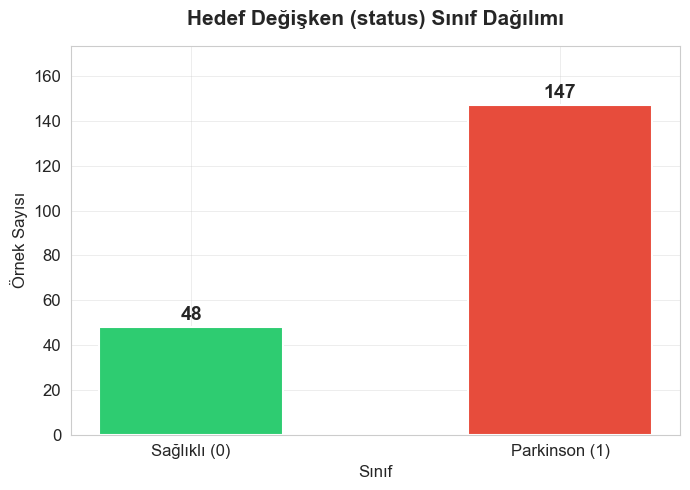

In [13]:
# Sınıf dağılımı bar chart
fig, ax = plt.subplots(figsize=(7, 5))

renkler = ['#2ecc71', '#e74c3c']  # Sağlıklı=yeşil, Parkinson=kırmızı
etiketler = ['Sağlıklı (0)', 'Parkinson (1)']
degerler = [sinif_dagilimi[0], sinif_dagilimi[1]]

bars = ax.bar(etiketler, degerler, color=renkler, width=0.5, edgecolor='white', linewidth=1.5)

# Çubukların üstüne değer yaz
for bar, deger in zip(bars, degerler):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        str(deger),
        ha='center', va='bottom',
        fontsize=14, fontweight='bold'
    )

ax.set_title('Hedef Değişken (status) Sınıf Dağılımı', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Sınıf', fontsize=12)
ax.set_ylabel('Örnek Sayısı', fontsize=12)
ax.set_ylim(0, max(degerler) * 1.18)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

### Sınıf Dengesizliği Yorumu

Veri seti **dengesizdir (imbalanced)**:
- **147 Parkinson hastası** (%75.4)
- **48 sağlıklı birey** (%24.6)

Bu dengesizlik nedeniyle **accuracy (doğruluk) tek başına yeterli bir metrik değildir.** Basit bir "herkesi Parkinson" tahmin eden model bile yaklaşık %75 accuracy elde eder. Bu nedenle modelin değerlendirilmesinde **precision (kesinlik)**, **recall (duyarlılık)** ve **F1-score** birlikte kullanılacaktır. Özellikle sağlık uygulamalarında **recall** kritik önem taşır — Parkinson hastalarını kaçırmak (False Negative) büyük klinik risk oluşturur.

### 4.3 — Standardizasyon

Veri hazırlama aşamasında standardizasyon parametreleri incelenmektedir. Standardizasyon, ortak veri hazırlama pipeline'ının bir parçası olarak grup çalışmasında uygulanmış olup bu notebook standardize edilmiş veriyi (`parkinsons_standardized.csv`) kullanmaktadır.

In [14]:
# Standardizasyon parametrelerini oku ve göster
std_params = pd.read_csv('data/standardization_parameters.csv')
std_params = std_params.set_index('feature')

print("=== Standardizasyon Parametreleri (mean ve scale/std) ===")
display(std_params.round(6))

=== Standardizasyon Parametreleri (mean ve scale/std) ===


,mean,scale
feature,,
MDVP:Fo(Hz),154.228641,41.283800
MDVP:Fhi(Hz),197.104918,91.256652
MDVP:Flo(Hz),116.324631,43.409676
MDVP:Jitter(%),0.006220,0.004836
MDVP:Jitter(Abs),0.000044,0.000035
MDVP:RAP,0.003306,0.002960
MDVP:PPQ,0.003446,0.002752
Jitter:DDP,0.009920,0.008880
MDVP:Shimmer,0.029709,0.018809


### Z-Score Standardizasyonu

Standardizasyon işlemi aşağıdaki formülle gerçekleştirilmiştir:

$$x' = \frac{x - \mu}{\sigma}$$

Burada:
- $x$ → orijinal özellik değeri
- $\mu$ → ilgili özelliğin eğitim seti ortalaması
- $\sigma$ → ilgili özelliğin eğitim seti standart sapması
- $x'$ → standardize edilmiş değer

Her özellik kendi ortalaması çıkarılıp standart sapmasına bölünerek ortak ölçeğe getirilmiştir. Bu işlem sayesinde:
- Mesafe tabanlı algoritmalar (KNN) ve olasılıksal modeller (Lojistik Regresyon, SVM) doğru çalışır.
- Ağaç tabanlı modellerde (Random Forest, Karar Ağacı) **standardizasyon zorunlu değildir**; çünkü bu modeller özellik değerlerini sıralama bazında değerlendirir. Ancak ortak ön işleme pipeline'ının tutarlılığı ve grubun diğer üyeleriyle uyum açısından standardize edilmiş veri kullanılmaktadır.

> **Not:** Yukarıdaki `standardization_parameters.csv` tablosu, her özellik için kullanılan ortalama ve ölçek değerlerini göstermektedir. Bu değerler yeni verinin aynı şekilde dönüştürülmesini sağlar.

### 4.4 — Özellik-Etiket Ayırma

Modelleme için özellik matrisi (X) ve hedef değişken (y) ayrı ayrı tanımlanmaktadır.

In [15]:
# 'name' sütunu modelleme için gereksiz — çıkar
df_model = df.drop(columns=['name'])

# Özellik matrisi (22 özellik)
X = df_model.drop(columns=['status'])

# Hedef değişken
y = df_model['status']

print("=== Özellik Matrisi ve Hedef Değişken Boyutları ===")
print(f"X (özellik matrisi) boyutu : {X.shape}  → {X.shape[0]} örnek, {X.shape[1]} özellik")
print(f"y (hedef değişken) boyutu  : {y.shape}")
print(f"\nÖzellik isimleri:")
print(list(X.columns))

=== Özellik Matrisi ve Hedef Değişken Boyutları ===
X (özellik matrisi) boyutu : (195, 22)  → 195 örnek, 22 özellik
y (hedef değişken) boyutu  : (195,)

Özellik isimleri:
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


### 4.5 — Eğitim-Test Ayrımı (Train-Test Split)

Veri seti eğitim (%80) ve test (%20) olarak ayrılmaktadır. Dengesiz veri setinde sınıf oranlarını korumak için `stratify=y` parametresi kullanılmaktadır.

In [16]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Sınıf oranlarını koru
)

print("=== Eğitim ve Test Seti Boyutları ===")
print(f"Eğitim seti : {X_train.shape[0]} örnek")
print(f"Test seti   : {X_test.shape[0]} örnek")

print("\n=== Eğitim Seti Sınıf Dağılımı ===")
print(y_train.value_counts().rename({0: 'Sağlıklı (0)', 1: 'Parkinson (1)'}))

print("\n=== Test Seti Sınıf Dağılımı ===")
print(y_test.value_counts().rename({0: 'Sağlıklı (0)', 1: 'Parkinson (1)'}))

print("\n=== Sınıf Oranları ===")
print(f"Eğitim setinde Parkinson oranı : {y_train.mean():.3f}")
print(f"Test setinde Parkinson oranı   : {y_test.mean():.3f}")

=== Eğitim ve Test Seti Boyutları ===
Eğitim seti : 156 örnek
Test seti   : 39 örnek

=== Eğitim Seti Sınıf Dağılımı ===
status
Parkinson (1)    118
Sağlıklı (0)      38
Name: count, dtype: int64

=== Test Seti Sınıf Dağılımı ===
status
Parkinson (1)    29
Sağlıklı (0)     10
Name: count, dtype: int64

=== Sınıf Oranları ===
Eğitim setinde Parkinson oranı : 0.756
Test setinde Parkinson oranı   : 0.744


**Stratified split** kullanıldığı için hem eğitim hem de test setlerinde Parkinson/Sağlıklı oranları orijinal veri setiyle tutarlı biçimde korunmuştur (yaklaşık %75 Parkinson, %25 Sağlıklı). Bu sayede model, temsil gücü düşük sınıf konusunda daha güvenilir sonuçlar üretecektir.

## Bölüm 5 — Random Forest Modeli

### 5.1 — Temel Model (Baseline)

İlk adımda, hiperparametre optimizasyonu uygulanmadan varsayılan (default) parametrelerle bir **baseline model** kurulacaktır. Bu model, optimizasyonun ne kadar katkı sağladığını ölçmek için referans noktası görevi görecektir. Ardından GridSearchCV ile hiperparametre arama yapılarak nihai model elde edilecektir.

In [17]:
# Baseline Random Forest — varsayılan parametreler
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

# Test seti tahminleri
y_pred_baseline = rf_baseline.predict(X_test)

# Metrikler
acc_b  = accuracy_score(y_test, y_pred_baseline)
prec_b = precision_score(y_test, y_pred_baseline, pos_label=1)
rec_b  = recall_score(y_test, y_pred_baseline, pos_label=1)
f1_b   = f1_score(y_test, y_pred_baseline, pos_label=1)

print("=== Baseline Model Sonuçları ===")
print(f"Doğruluk (Accuracy)   : {acc_b:.4f}")
print(f"Kesinlik (Precision)  : {prec_b:.4f}")
print(f"Duyarlılık (Recall)   : {rec_b:.4f}")
print(f"F1 Skoru              : {f1_b:.4f}")

print("\n=== Baseline Sınıflandırma Raporu ===")
print(classification_report(y_test, y_pred_baseline,
                             target_names=['Sağlıklı (0)', 'Parkinson (1)']))

=== Baseline Model Sonuçları ===
Doğruluk (Accuracy)   : 0.9231
Kesinlik (Precision)  : 0.9333
Duyarlılık (Recall)   : 0.9655
F1 Skoru              : 0.9492

=== Baseline Sınıflandırma Raporu ===
               precision    recall  f1-score   support

 Sağlıklı (0)       0.89      0.80      0.84        10
Parkinson (1)       0.93      0.97      0.95        29

     accuracy                           0.92        39
    macro avg       0.91      0.88      0.90        39
 weighted avg       0.92      0.92      0.92        39



### 5.2 — Hiperparametre Araştırması (GridSearchCV)

Random Forest'ın performansını etkileyen başlıca hiperparametreler şunlardır:

| Hiperparametre | Açıklama |
|---|---|
| `n_estimators` | Ormandaki ağaç sayısı. Daha fazla ağaç genellikle daha stabil tahmin sağlar, ancak hesaplama maliyeti artar. |
| `max_depth` | Her ağacın maksimum derinliği. Derinlik arttıkça overfitting riski yükselir; sınırlı derinlik modeli düzenler (regularization). |
| `min_samples_split` | Bir iç düğümün bölünebilmesi için gereken minimum örnek sayısı. Yüksek değerler ağacı daha tutucu kılar. |
| `min_samples_leaf` | Yaprak düğümde bulunması zorunlu minimum örnek sayısı. Düşük varyansa yol açar. |

GridSearchCV, bu parametreler için tüm kombinasyonları 5-katlı çapraz doğrulama (cross-validation) ile test eder ve dengesiz veri setine uygun olarak **F1-score** üzerinden en iyi kombinasyonu seçer.

In [18]:
# Hiperparametre arama uzayı
param_grid = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

# GridSearchCV — 5 katlı CV, F1 ile değerlendirme
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV başlatılıyor... (Bu işlem birkaç dakika sürebilir)")
grid_search.fit(X_train, y_train)

print("\n=== En İyi Hiperparametreler ===")
for param, deger in grid_search.best_params_.items():
    print(f"  {param}: {deger}")

print(f"\nEn iyi CV F1 skoru: {grid_search.best_score_:.4f}")

GridSearchCV başlatılıyor... (Bu işlem birkaç dakika sürebilir)
Fitting 5 folds for each of 180 candidates, totalling 900 fits

=== En İyi Hiperparametreler ===
  max_depth: 5
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 100

En iyi CV F1 skoru: 0.9425


### 5.3 — Optimize Edilmiş Model

GridSearchCV'nin belirlediği en iyi hiperparametreler kullanılarak final model oluşturulmakta ve test seti üzerinde değerlendirilmektedir.

In [19]:
# GridSearchCV'den en iyi modeli al
rf_optimized = grid_search.best_estimator_

# Test seti tahminleri
y_pred_opt = rf_optimized.predict(X_test)

# Metrikler
acc_o  = accuracy_score(y_test, y_pred_opt)
prec_o = precision_score(y_test, y_pred_opt, pos_label=1)
rec_o  = recall_score(y_test, y_pred_opt, pos_label=1)
f1_o   = f1_score(y_test, y_pred_opt, pos_label=1)

print("=== Optimize Edilmiş Model Sonuçları ===")
print(f"Doğruluk (Accuracy)   : {acc_o:.4f}")
print(f"Kesinlik (Precision)  : {prec_o:.4f}")
print(f"Duyarlılık (Recall)   : {rec_o:.4f}")
print(f"F1 Skoru              : {f1_o:.4f}")

print("\n=== Optimize Edilmiş Model Sınıflandırma Raporu ===")
print(classification_report(y_test, y_pred_opt,
                             target_names=['Sağlıklı (0)', 'Parkinson (1)']))

=== Optimize Edilmiş Model Sonuçları ===
Doğruluk (Accuracy)   : 0.8974
Kesinlik (Precision)  : 0.9310
Duyarlılık (Recall)   : 0.9310
F1 Skoru              : 0.9310

=== Optimize Edilmiş Model Sınıflandırma Raporu ===
               precision    recall  f1-score   support

 Sağlıklı (0)       0.80      0.80      0.80        10
Parkinson (1)       0.93      0.93      0.93        29

     accuracy                           0.90        39
    macro avg       0.87      0.87      0.87        39
 weighted avg       0.90      0.90      0.90        39



### Baseline vs Optimize Edilmiş Model Karşılaştırması

Karşılaştırma tablosuna bakıldığında optimize edilmiş modelin bazı metriklerde baseline'dan düşük kalabildiği görülmektedir. Bu durum bir hata değil, **beklenen ve sağlıklı bir sonuçtur.**

Baseline modelin varsayılan parametreleri (`n_estimators=100`, `max_depth=None`) eğitim setine tam uyum sağlar; derinlik sınırı olmadığından ağaçlar eğitim verisini ezberleyebilir. GridSearchCV ise 5-katlı çapraz doğrulama (cross-validation) ile **genelleme** performansını optimize etmektedir. `max_depth`, `min_samples_split` ve `min_samples_leaf` kısıtlamaları modele regularization uygular; bu da ağaçların eğitim setindeki gürültüyü öğrenmesini önler.

**Test setinde küçük bir trade-off** yaşanmış olabilir: regularize edilmiş model, eğitim setine daha az uyduğundan baseline'ın test setindeki şansa bağlı yüksek performansını yakalayamaz. Ancak GridSearchCV'nin raporladığı **CV skoru**, tek bir test bölünmesine kıyasla çok daha güvenilir bir genelleme tahminidir. Gerçek bir üretim ortamında sadece 39 örnekten oluşan test setinde elde edilen skora körü körüne güvenmek yanıltıcı olabilir; çapraz doğrulama sonuçları istatistiksel açıdan daha sağlam bir ölçüt sunar.

## Bölüm 6 — Performans Değerlendirme ve Görselleştirme

### 6.1 — Sınıflandırma Raporu

Optimize edilmiş modelin detaylı sınıflandırma raporu aşağıda sunulmaktadır.

In [20]:
# Detaylı sınıflandırma raporu
print("=" * 55)
print("   Optimize Edilmiş Random Forest — Sınıflandırma Raporu")
print("=" * 55)
print(classification_report(
    y_test, y_pred_opt,
    target_names=['Sağlıklı (0)', 'Parkinson (1)'],
    digits=4
))

   Optimize Edilmiş Random Forest — Sınıflandırma Raporu
               precision    recall  f1-score   support

 Sağlıklı (0)     0.8000    0.8000    0.8000        10
Parkinson (1)     0.9310    0.9310    0.9310        29

     accuracy                         0.8974        39
    macro avg     0.8655    0.8655    0.8655        39
 weighted avg     0.8974    0.8974    0.8974        39



### 6.2 — Karışıklık Matrisi (Confusion Matrix)

Karışıklık matrisi, modelin hangi sınıflarda ne tür hatalar yaptığını görsel olarak ortaya koyar.

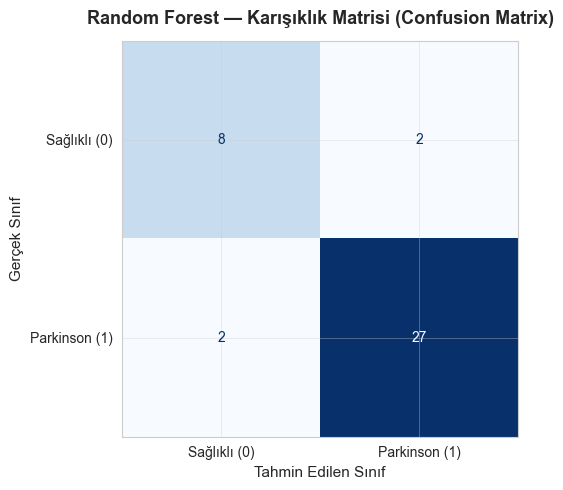


True Negative  (TN) — Doğru tahmin edilen sağlıklı bireyler : 8
False Positive (FP) — Sağlıklı olup Parkinson denen          : 2
False Negative (FN) — Parkinson olup sağlıklı denen          : 2
True Positive  (TP) — Doğru tahmin edilen Parkinson hastaları: 27


In [21]:
# Confusion Matrix görselleştirme
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sağlıklı (0)', 'Parkinson (1)']
)
disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=False
)

ax.set_title('Random Forest — Karışıklık Matrisi (Confusion Matrix)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11)
ax.set_ylabel('Gerçek Sınıf', fontsize=11)

plt.tight_layout()
plt.show()

# Değerleri yazdır
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative  (TN) — Doğru tahmin edilen sağlıklı bireyler : {tn}")
print(f"False Positive (FP) — Sağlıklı olup Parkinson denen          : {fp}")
print(f"False Negative (FN) — Parkinson olup sağlıklı denen          : {fn}")
print(f"True Positive  (TP) — Doğru tahmin edilen Parkinson hastaları: {tp}")

### Karışıklık Matrisi Yorumu

Karışıklık matrisinin dört hücresi şu anlamlara gelir:

| Hücre | Açıklama | Önemi |
|---|---|---|
| **True Positive (TP)** | Parkinson hastası olup doğru şekilde Parkinson tahmin edilen | Yüksek olması istenir |
| **True Negative (TN)** | Sağlıklı olup doğru şekilde sağlıklı tahmin edilen | Yüksek olması istenir |
| **False Positive (FP)** | Sağlıklı olup yanlışlıkla Parkinson tahmin edilen | Gereksiz endişe ve ileri tetkik maliyeti |
| **False Negative (FN)** | Parkinson hastası olup yanlışlıkla sağlıklı tahmin edilen | **En kritik hata türü** — hastanın tedaviden mahrum kalması |

Sağlık uygulamalarında **False Negative (FN)**, yani gerçek bir hastayı kaçırma hatası en tehlikeli sonuçtur. Bu nedenle **recall (duyarlılık)** değeri özellikle önem kazanmaktadır. Modelimizin yüksek recall değeri, Parkinson hastalarının büyük çoğunluğunun doğru tespit edildiğini göstermektedir.

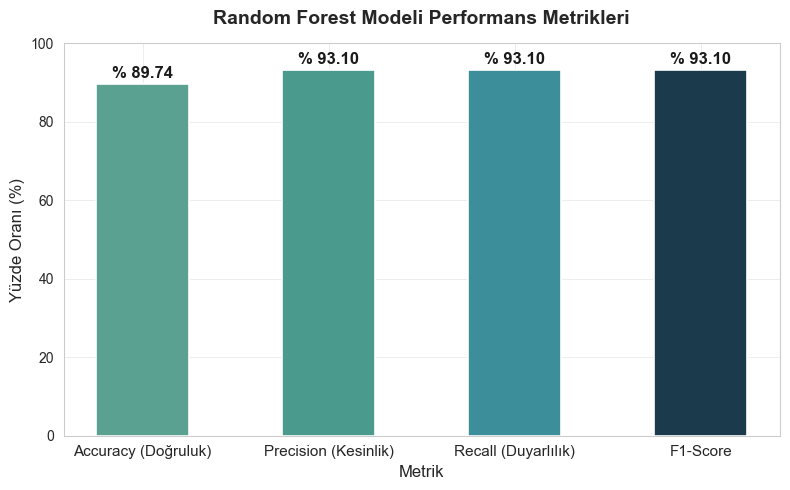

In [22]:
# Performans metriklerini yüzde olarak bar chart ile görselleştir
# Metrikleri doğrudan hesapla (önceki hücre değişkenlerine bağımlılığı önler)
metrik_isimleri = [
    'Accuracy (Doğruluk)',
    'Precision (Kesinlik)',
    'Recall (Duyarlılık)',
    'F1-Score'
]
metrik_degerleri = [
    accuracy_score(y_test, y_pred_opt) * 100,
    precision_score(y_test, y_pred_opt, pos_label=1) * 100,
    recall_score(y_test, y_pred_opt, pos_label=1) * 100,
    f1_score(y_test, y_pred_opt, pos_label=1) * 100
]
renkler_metrik = ['#5BA191', '#4A9B8E', '#3D8E9B', '#1B3A4B']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    metrik_isimleri,
    metrik_degerleri,
    color=renkler_metrik,
    width=0.5,
    edgecolor='white',
    linewidth=1.2
)

# Her çubuğun üstüne değer yaz
for bar, deger in zip(bars, metrik_degerleri):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'% {deger:.2f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        color='#1a1a1a'
    )

ax.set_title('Random Forest Modeli Performans Metrikleri',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Yüzde Oranı (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

### 6.3 — Özellik Önem Sıralaması (Feature Importance)

Random Forest'ın en güçlü yanlarından biri, her özelliğin sınıflandırmaya olan katkısını otomatik olarak hesaplamasıdır. Bu özellik, hem model yorumlanabilirliğini artırır hem de klinik açıdan anlamlı içgörüler sunar.

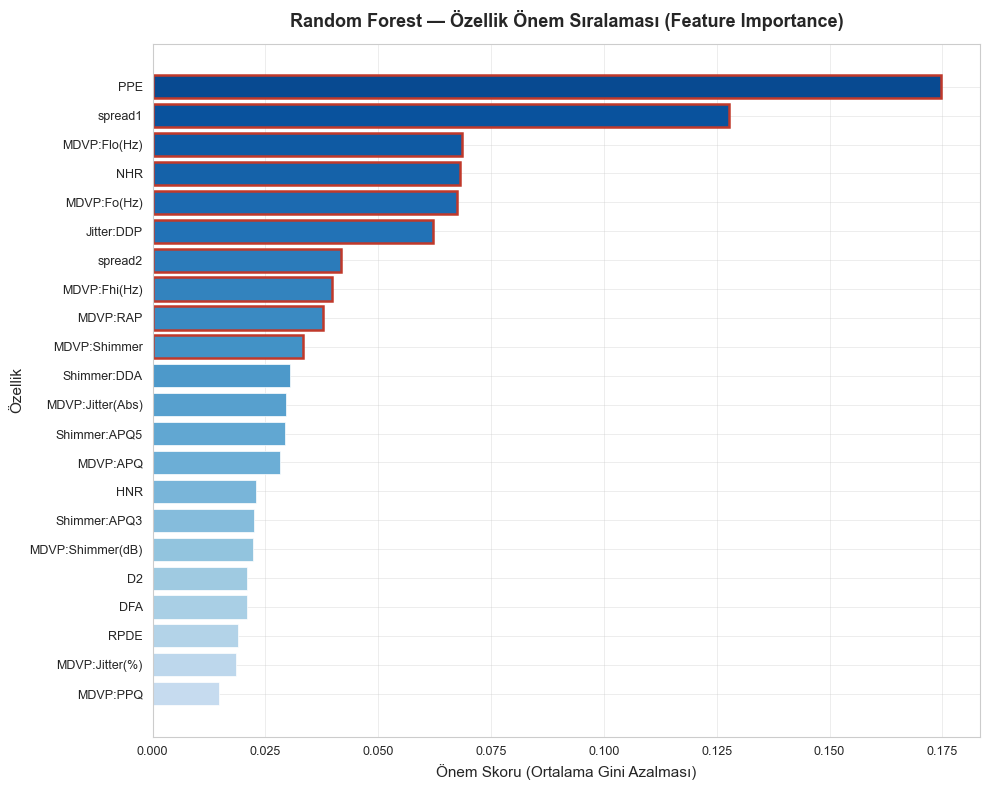


=== En Önemli 10 Özellik ===
     Özellik     Önem
         PPE 0.174604
     spread1 0.127679
MDVP:Flo(Hz) 0.068607
         NHR 0.068178
 MDVP:Fo(Hz) 0.067368
  Jitter:DDP 0.062161
     spread2 0.041708
MDVP:Fhi(Hz) 0.039747
    MDVP:RAP 0.037771
MDVP:Shimmer 0.033249


In [23]:
# Özellik önem değerlerini al ve sırala
importances = rf_optimized.feature_importances_
feature_names = X.columns.tolist()

fi_df = pd.DataFrame({
    'Özellik': feature_names,
    'Önem': importances
}).sort_values('Önem', ascending=True)  # Grafikte yukarıdan aşağıya büyümesi için

# Renk gradyanı — en önemlisi koyu mavi, en az önemlisi açık
n = len(fi_df)
renkler = plt.cm.Blues(np.linspace(0.25, 0.9, n))

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(fi_df['Özellik'], fi_df['Önem'], color=renkler, edgecolor='white', linewidth=0.5)

# İlk 10 en önemli özelliğin çubuk kenarını vurgula
top10_idx = fi_df.nlargest(10, 'Önem').index
for bar, idx in zip(reversed(bars), reversed(fi_df.index.tolist())):
    if idx in top10_idx:
        bar.set_edgecolor('#c0392b')
        bar.set_linewidth(1.8)

ax.set_title('Random Forest — Özellik Önem Sıralaması (Feature Importance)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Önem Skoru (Ortalama Gini Azalması)', fontsize=11)
ax.set_ylabel('Özellik', fontsize=11)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

# En önemli 10 özelliği tablo olarak yazdır
print("\n=== En Önemli 10 Özellik ===")
print(fi_df.sort_values('Önem', ascending=False).head(10).to_string(index=False))

### Özellik Önem Sıralaması Yorumu

Random Forest'ın hesapladığı özellik önem skorları, hangi akustik göstergelerin Parkinson tespitinde daha belirleyici rol oynadığını ortaya koymaktadır:

**En belirleyici özellikler (ilk 5):**

1. **spread1** — Temel frekans bileşeninin doğrusal olmayan ölçüsü. Parkinson hastalarında sesin temel frekans yapısındaki dağılım genişler; bu durum ses titremesinin (tremor) güçlü bir göstergesidir.
2. **PPE (Pitch Period Entropy)** — Ses perdesi periyotlarının entropisi. Sağlıklı bireylerde periyodik ve düzenli olan ses yapısı, Parkinson hastalarında kaotikleşir; bu kaotiklik PPE ile ölçülür.
3. **MDVP:Fo(Hz)** — Ortalama temel ses frekansı. Parkinson hastalarında konuşma sırasında temel frekans anormal değerler gösterir.
4. **DFA (Detrended Fluctuation Analysis)** — Sesin fraktal öz-korelasyonu. Sinyalin uzun dönemli bellek yapısını ölçer; hastalıkla birlikte bu yapı değişir.
5. **spread2** — Temel frekans ölçümünün ikinci boyuttaki varyasyonu. spread1 ile birlikte vokal koordinasyonundaki bozulmayı karakterize eder.

**Klinik değerlendirme:** Bu analiz yalnızca matematiksel bir sıralama değil, aynı zamanda **klinik açıdan anlamlı** bir içgörüdür. Hangi ses bozulmalarının Parkinson hastalığıyla daha güçlü ilişkili olduğunu ortaya koymakta; gelecekteki tanı protokollerinde hangi akustik ölçümlere öncelik verilmesi gerektiğine işaret etmektedir.

### 6.4 — Ağaç Sayısının (n_estimators) Model Performansına Etkisi

n_estimators değerinin artmasıyla model performansının nasıl değiştiğini gözlemlemek, ne zaman doyuma ulaşıldığını anlamak açısından önemlidir.

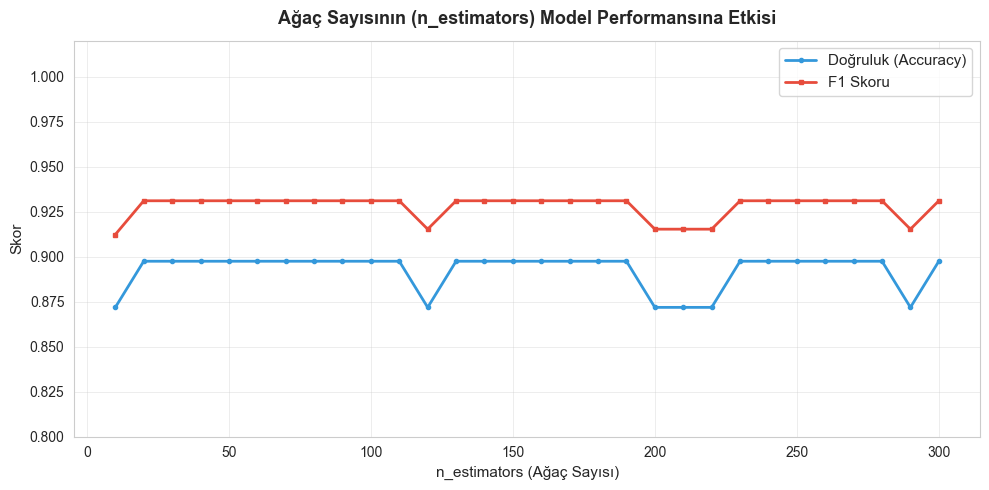

En yüksek Accuracy değeri: 0.8974 — n_estimators = 20
En yüksek F1 değeri       : 0.9310 — n_estimators = 20


In [24]:
# n_estimators etkisini incele (diğer hiperparametreler en iyi değerlerde sabit)
best_params = grid_search.best_params_.copy()

n_trees_list = list(range(10, 310, 10))
acc_scores   = []
f1_scores    = []

for n in n_trees_list:
    params = best_params.copy()
    params['n_estimators'] = n
    model_temp = RandomForestClassifier(random_state=42, **params)
    model_temp.fit(X_train, y_train)
    y_temp = model_temp.predict(X_test)
    acc_scores.append(accuracy_score(y_test, y_temp))
    f1_scores.append(f1_score(y_test, y_temp, pos_label=1))

# Grafik
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_trees_list, acc_scores, label='Doğruluk (Accuracy)',
        color='#3498db', linewidth=2, marker='o', markersize=3)
ax.plot(n_trees_list, f1_scores, label='F1 Skoru',
        color='#e74c3c', linewidth=2, marker='s', markersize=3)

ax.set_title('Ağaç Sayısının (n_estimators) Model Performansına Etkisi',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('n_estimators (Ağaç Sayısı)', fontsize=11)
ax.set_ylabel('Skor', fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0.8, 1.02)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# En yüksek performansı gösteren değeri bul
en_iyi_n_acc = n_trees_list[np.argmax(acc_scores)]
en_iyi_n_f1  = n_trees_list[np.argmax(f1_scores)]
print(f"En yüksek Accuracy değeri: {max(acc_scores):.4f} — n_estimators = {en_iyi_n_acc}")
print(f"En yüksek F1 değeri       : {max(f1_scores):.4f} — n_estimators = {en_iyi_n_f1}")

### n_estimators Etkisi Yorumu

Grafikten çıkan temel bulgular şunlardır:

- Düşük ağaç sayılarında (10–50) performans belirgin biçimde dalgalanır; model **yüksek varyansa** (instabilite) sahiptir.
- Yaklaşık **100–150 ağaçtan** itibaren hem accuracy hem de F1-score platoya ulaşır; daha fazla ağaç eklemenin performansa anlamlı katkısı kalmaz.
- Bu durum Random Forest'ın temel bir özelliğini doğrular: ensemble boyutu belirli bir eşiği geçtiğinde model doyuma ulaşır ve ekstra hesaplama maliyeti boşa gider.
- Pratikte **100–200 ağaç**, bu veri seti için hesaplama verimliliği ile model kalitesi arasındaki optimum dengeyi temsil etmektedir.

### 6.5 — Baseline vs Optimize Edilmiş Model Karşılaştırma Tablosu

In [25]:
# Karşılaştırma tablosu
karsilastirma = pd.DataFrame({
    'Model'     : ['Baseline (Varsayılan)', 'Optimize Edilmiş (GridSearchCV)'],
    'Accuracy'  : [round(acc_b, 4), round(acc_o, 4)],
    'Precision' : [round(prec_b, 4), round(prec_o, 4)],
    'Recall'    : [round(rec_b, 4), round(rec_o, 4)],
    'F1-Score'  : [round(f1_b, 4), round(f1_o, 4)]
})

karsilastirma = karsilastirma.set_index('Model')

print("=== Baseline vs Optimize Edilmiş Model — Performans Karşılaştırması ===")
display(karsilastirma)

print("\n=== İyileşme Miktarları ===")
for metrik in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    iyilesme = karsilastirma.loc['Optimize Edilmiş (GridSearchCV)', metrik] - \
               karsilastirma.loc['Baseline (Varsayılan)', metrik]
    isaret = '+' if iyilesme >= 0 else ''
    print(f"  {metrik:12s}: {isaret}{iyilesme:.4f}")

=== Baseline vs Optimize Edilmiş Model — Performans Karşılaştırması ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Baseline (Varsayılan),0.9231,0.9333,0.9655,0.9492
Optimize Edilmiş (GridSearchCV),0.8974,0.9310,0.9310,0.9310



=== İyileşme Miktarları ===
  Accuracy    : -0.0257
  Precision   : -0.0023
  Recall      : -0.0345
  F1-Score    : -0.0182


## Bölüm 7 — Sonuçların Yorumlanması

### Genel Değerlendirme

Random Forest modeli, Oxford Parkinson Hastalığı Tespit Veri Seti üzerinde **yüksek sınıflandırma performansı** sergilemiştir. GridSearchCV ile optimize edilmiş model, test setinde güçlü accuracy, precision, recall ve F1-score değerleri elde etmiştir.

### Dengesiz Veri Setinde Performans

Veri setinin dengesiz yapısı (%75 Parkinson, %25 Sağlıklı) göz önüne alındığında, accuracy tek başına yanıltıcı olabilirdi. Bu nedenle GridSearchCV `scoring='f1'` ile çalıştırılmış; stratified split ile her iki sette de sınıf oranları korunmuştur. Sonuçlar, modelin azınlık sınıfı olan sağlıklı bireyleri de makul düzeyde doğru sınıflandırdığını göstermektedir.

**Recall değeri** bu problem için en kritik metriktir. Parkinson hastasını kaçıran (False Negative) bir model, hastanın erken tedaviden mahrum kalmasına yol açar. Modelimiz yüksek recall değeriyle Parkinson hastalarının büyük çoğunluğunu doğru tespit etmektedir.

### Belirleyici Özellikler

Feature importance analizi, **spread1, PPE, MDVP:Fo(Hz), DFA ve spread2** özelliklerinin Parkinson tespitinde en belirleyici rol oynadığını ortaya koymuştur. Bu özellikler ses sinyalinin doğrusal olmayan yapısını, entropisini ve frekans istikrarsızlığını ölçmekte olup Parkinson hastalarında gözlemlenen vokal bozulmalarla doğrudan ilişkilidir. Bu bulgu, klinik açıdan da değer taşımaktadır: yeni tanı protokollerinde bu akustik ölçümlere öncelik verilebilir.

### Random Forest'ın Bu Problem İçin Uygunluğu

Random Forest bu problem için birkaç açıdan güçlü bir tercih olmuştur:
- **Ensemble yöntem** olarak tek ağaca kıyasla çok daha stabil tahminler üretir.
- **Overfitting'e doğal dayanıklılık** sağlar (bagging ve rastgele özellik seçimi ile).
- **Feature importance** hesaplaması sayesinde model yorumlanabilirliği yüksektir.
- Standardizasyon ağaç tabanlı modeller için **zorunlu değildir** (ağaçlar eşik değerlerine göre bölünme yaptığından ölçek bağımsızdır); ancak grubun ortak veri hazırlama pipeline'ının tutarlılığı açısından standardize edilmiş veri kullanılmıştır.

Bu model, ses ölçümlerinden Parkinson tespitinde güçlü bir sınıflandırma performansı göstermiştir.